
Korak 1:
State (first 8): [0.65 0.67 0.49 0.32 0.38 0.1  0.38 0.52] ...
RAW akcija:  [0, 1, 0] | {'pit': 'NE', 'compound': '1 (MEDIUM)', 'style': '0 (Konzervativno)'}
SAFE akcija: [1, 1, 0] | {'pit': 'DA', 'compound': '1 (MEDIUM)', 'style': '0 (Konzervativno)'}
Overrides: 1 | Violations: 1
 - pit: 0 -> 1 (R4_LOW_TYRE_FORCES_PIT)
Reward: 1.90
------------------------------------------------------------

Korak 2:
State (first 8): [0.33 0.44 0.67 0.66 0.56 0.67 0.68 0.45] ...
RAW akcija:  [0, 1, 0] | {'pit': 'NE', 'compound': '1 (MEDIUM)', 'style': '0 (Konzervativno)'}
SAFE akcija: [1, 1, 0] | {'pit': 'DA', 'compound': '1 (MEDIUM)', 'style': '0 (Konzervativno)'}
Overrides: 1 | Violations: 1
 - pit: 0 -> 1 (R4_LOW_TYRE_FORCES_PIT)
Reward: 1.94
------------------------------------------------------------

Korak 3:
State (first 8): [0.02 0.57 0.69 0.42 0.01 0.62 0.45 0.34] ...
RAW akcija:  [0, 1, 0] | {'pit': 'NE', 'compound': '1 (MEDIUM)', 'style': '0 (Konzervativno)'}
SAFE akcija: [1, 1, 

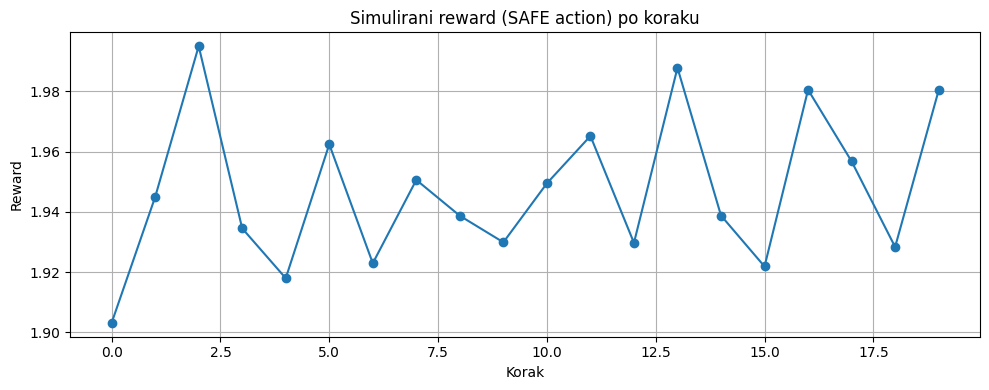


Override rate u epizodi: 1.0


In [9]:
# === main.ipynb – Interaktivna biljeznica za testiranje F1 RL agenta + LOGIC LAYER ===

# Pokretanje FastAPI servera mora biti u drugom terminalu:
# uvicorn api:app --reload

# Ako nedostaje/nije instaliran paket:
# pip install requests numpy matplotlib

# Pazi da pokretanje bude ovako u odgovarajucem direktoriju:cd "VS_Code verzija-finall"
# Pokretanje: python -m uvicorn api:app --reload --host 127.0.0.1 --port 8000

import requests
import numpy as np
import matplotlib.pyplot as plt
import time
from utils import selected_features  # <-- KLJUČNO: prava dimenzija stanja

# Endpoint REST API-ja
url = "http://127.0.0.1:8000/predict_strategy"
N_FEATURES = len(selected_features)

def simulate_episode(n_steps=20, verbose=True):
    rewards = []
    safe_actions = []
    raw_actions = []
    override_flags = []  # 1 ako je logika nešto promijenila, 0 ako nije

    # Dummy stanje, ali ispravne dimenzije
    state = np.random.rand(N_FEATURES).tolist()

    for step in range(n_steps):
        response = requests.post(url, json={"state": state})
        if response.status_code != 200:
            raise RuntimeError(f"API error {response.status_code}: {response.text}")

        data = response.json()

        # API vraća "action" = SAFE action (nakon logike) + "explanation"
        safe_action = data["action"]
        explanation = data.get("explanation", {})

        raw_action = explanation.get("raw_action", None)
        overrides = explanation.get("logic", {}).get("overrides", [])
        was_overridden = 1 if overrides else 0

        # Dummy reward (samo za demo)
        reward = float(np.sum(safe_action)) - 0.1 * np.random.rand()

        rewards.append(reward)
        safe_actions.append(safe_action)
        raw_actions.append(raw_action if raw_action is not None else [-1, -1, -1])
        override_flags.append(was_overridden)

        if verbose:
            print(f"\nKorak {step+1}:")
            print(f"State (first 8): {np.round(state[:8], 2)} ...")
            print(f"RAW akcija:  {raw_action} | {explanation.get('raw_human')}")
            print(f"SAFE akcija: {safe_action} | {explanation.get('safe_human')}")
            print(f"Overrides: {len(overrides)} | Violations: {len(explanation.get('logic', {}).get('violations_before', []))}")
            if overrides:
                for o in overrides:
                    print(f" - {o['field']}: {o['from']} -> {o['to']} ({o['rule']})")
            print(f"Reward: {reward:.2f}")
            print("-" * 60)

        # Ažuriraj stanje (dummy dinamika, ali ispravne dimenzije)
        state = (np.random.rand(N_FEATURES) * (0.5 + reward / 10)).tolist()
        time.sleep(0.05)

    return rewards, np.array(raw_actions), np.array(safe_actions), np.array(override_flags)

# Pokreni simulaciju
rewards, raw_actions, safe_actions, override_flags = simulate_episode(n_steps=20, verbose=True)

# === Graf: Reward po koraku ===
plt.figure(figsize=(10, 4))
plt.plot(rewards, marker='o')
plt.title("Simulirani reward (SAFE action) po koraku")
plt.xlabel("Korak")
plt.ylabel("Reward")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nOverride rate u epizodi:", override_flags.mean())


In [10]:
# API testovi (single + batch + explain) s pravom dimenzijom i čitljivim ispisom
import requests
import numpy as np
from utils import selected_features

BASE_URL = "http://127.0.0.1:8000"
N_FEATURES = len(selected_features)

def generate_dummy_state(n=N_FEATURES):
    return (np.random.rand(n)).tolist()

# === 1. predict_strategy ===
def test_predict_strategy():
    url = f"{BASE_URL}/predict_strategy"
    state = generate_dummy_state()
    response = requests.post(url, json={"state": state})
    print("=== /predict_strategy ===")
    if response.status_code != 200:
        print("ERROR:", response.status_code, response.text)
        return None

    data = response.json()
    exp = data.get("explanation", {})

    print("SAFE action:", data.get("action"), "|", exp.get("safe_human"))
    print("RAW action :", exp.get("raw_action"), "|", exp.get("raw_human"))

    logic = exp.get("logic", {})
    print("Overrides:", len(logic.get("overrides", [])))
    print("Violations before:", len(logic.get("violations_before", [])))
    if logic.get("overrides"):
        for o in logic["overrides"]:
            print(f" - {o['field']}: {o['from']} -> {o['to']} ({o['rule']})")

    return data

# === 2. predict_strategy_batch ===
def test_predict_strategy_batch(batch_size=5):
    url = f"{BASE_URL}/predict_strategy_batch"
    states = [{"state": generate_dummy_state()} for _ in range(batch_size)]
    response = requests.post(url, json=states)

    print("\n=== /predict_strategy_batch ===")
    if response.status_code != 200:
        print("ERROR:", response.status_code, response.text)
        return None

    data = response.json()
    summary = data.get("summary", {})
    print("SUMMARY:", summary)

    # prikaz prvog rezultata
    results = data.get("results", [])
    if results:
        first = results[0]
        print("\nFirst result:")
        print("RAW:", first.get("raw_action"), "|", first.get("raw_human"))
        print("SAFE:", first.get("safe_action"), "|", first.get("safe_human"))
        print("Logic:", first.get("logic"))

    return data

# === 3. explain_strategy ===
def test_explain_strategy():
    url = f"{BASE_URL}/explain_strategy"
    state = generate_dummy_state()
    response = requests.post(url, json={"state": state})

    print("\n=== /explain_strategy ===")
    if response.status_code != 200:
        print("ERROR:", response.status_code, response.text)
        return None

    print("Response:", response.json())
    return response.json()

# === Pokreni testove ===
predict_result = test_predict_strategy()
batch_result = test_predict_strategy_batch(batch_size=8)
explanation_result = test_explain_strategy()

=== /predict_strategy ===
SAFE action: [1, 1, 0] | {'pit': 'DA', 'compound': '1 (MEDIUM)', 'style': '0 (Konzervativno)'}
RAW action : [0, 1, 1] | {'pit': 'NE', 'compound': '1 (MEDIUM)', 'style': '1 (Neutralno)'}
Overrides: 2
Violations before: 2
 - pit: 0 -> 1 (R4_LOW_TYRE_FORCES_PIT)
 - style: 1 -> 0 (R7_SMALL_GAP_CONSERVATIVE)

=== /predict_strategy_batch ===
SUMMARY: {'n': 8, 'override_rate': 1.0, 'violation_rate_raw': 1.0, 'top_rules': [['R4_LOW_TYRE_FORCES_PIT', 8], ['R5_BLOCK_POINTLESS_PIT', 8], ['R6_WET_AVOIDS_AGGRESSIVE', 8], ['R7_SMALL_GAP_CONSERVATIVE', 8], ['R8_BIG_GAP_DRY_MORE_AGGRESSIVE', 8], ['R3_DRY_RULES', 5]]}

First result:
RAW: [0, 1, 1] | {'pit': 'NE', 'compound': '1 (MEDIUM)', 'style': '1 (Neutralno)'}
SAFE: [1, 1, 0] | {'pit': 'DA', 'compound': '1 (MEDIUM)', 'style': '0 (Konzervativno)'}
Logic: {'violations_before': ['R4: TyreLife jako nizak -> PIT mora biti 1', 'R7: Mali front gap -> preferiraj konzervativno'], 'overrides': [{'field': 'pit', 'from': 0, 'to': 1, '

Logic layer override rate: 63.50%
Violations (raw): 48.52%
Overrides by field: pit=22, compound=278, style=174

Točnost predikcije (RAW = bez logike):
Pit stop:     97.48%
Compound:     48.22%
Driving style:32.49%

Točnost predikcije (SAFE = s logikom):
Pit stop:     94.21%
Compound:     89.47%
Driving style:42.14%


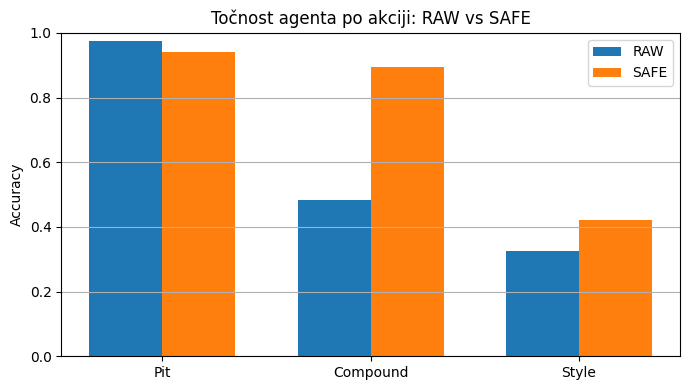

In [ ]:
# Offline evaluacija modela + logički sloj (RAW vs SAFE accuracy) bez API-ja
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from stable_baselines3 import PPO

from utils import selected_features
from logic_layer import verify_action

# === Učitaj model i podatke ===
# Zamijeni na svoj final model:
model = PPO.load("saved_models/ppo_f1_rl_logic_v4_retrained.zip")

obs_array = np.load("data/obs_array.npy")
true_actions = np.load("data/true_actions.npy")

raw_actions = []
safe_actions = []

viol_before = 0
overrides_count = 0

pit_overrides = 0
comp_overrides = 0
style_overrides = 0

for obs in obs_array:
    obs_2d = obs.reshape(1, -1)
    action, _ = model.predict(obs_2d, deterministic=True)
    raw = action[0] if isinstance(action[0], (list, np.ndarray)) else action
    raw = np.array(raw, dtype=np.int32)

    safe, report = verify_action(obs, raw, selected_features)

    raw_actions.append(raw)
    safe_actions.append(safe)

    if report.violations_before:
        viol_before += 1
    if report.overrides:
        overrides_count += 1

    for o in report.overrides:
        if o["field"] == "pit":
            pit_overrides += 1
        elif o["field"] == "compound":
            comp_overrides += 1
        elif o["field"] == "style":
            style_overrides += 1

raw_actions = np.array(raw_actions, dtype=np.int32)
safe_actions = np.array(safe_actions, dtype=np.int32)

# === Accuracy RAW vs SAFE ===
acc_pit_raw = accuracy_score(true_actions[:, 0], raw_actions[:, 0])
acc_comp_raw = accuracy_score(true_actions[:, 1], raw_actions[:, 1])
acc_style_raw = accuracy_score(true_actions[:, 2], raw_actions[:, 2])

acc_pit_safe = accuracy_score(true_actions[:, 0], safe_actions[:, 0])
acc_comp_safe = accuracy_score(true_actions[:, 1], safe_actions[:, 1])
acc_style_safe = accuracy_score(true_actions[:, 2], safe_actions[:, 2])

n = len(obs_array)

print(f"Logic layer override rate: {overrides_count/n:.2%}" if n else "No samples.")
print(f"Violations (raw): {viol_before/n:.2%}" if n else "No samples.")
print(f"Overrides by field: pit={pit_overrides}, compound={comp_overrides}, style={style_overrides}")

print("\nTočnost predikcije (RAW = bez logike):")
print(f"Pit stop:     {acc_pit_raw:.2%}")
print(f"Compound:     {acc_comp_raw:.2%}")
print(f"Driving style:{acc_style_raw:.2%}")

print("\nTočnost predikcije (SAFE = s logikom):")
print(f"Pit stop:     {acc_pit_safe:.2%}")
print(f"Compound:     {acc_comp_safe:.2%}")
print(f"Driving style:{acc_style_safe:.2%}")

# === Graf točnosti ===
labels = ["Pit", "Compound", "Style"]
raw_vals = [acc_pit_raw, acc_comp_raw, acc_style_raw]
safe_vals = [acc_pit_safe, acc_comp_safe, acc_style_safe]

x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - w/2, raw_vals, width=w, label="RAW")
plt.bar(x + w/2, safe_vals, width=w, label="SAFE")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.title("Točnost agenta po akciji: RAW vs SAFE")
plt.ylabel("Accuracy")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()
plt.show()